In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with open("../scripts/_cache/resnet18_imagenet_2_per_class_fourier_vs_smoothing.json") as f:
    resnet18_saved = json.load(f)

with open("../scripts/_cache/roberta_tweeteval_sentiment_fourier_vs_smoothing.json") as f:
    roberta_saved = json.load(f)

In [3]:
resnet18_saved.keys()

dict_keys(['model_name', 'dataset_name', 'max_samples_from_dataset', 'lambdas', 'lambda_to_avg_mass', 'lambda_to_max_mass', 'lambda_to_avg_variance', 'lambda_to_max_variance'])

In [4]:
resnet18_saved["lambda_to_max_mass"]["1.000"]

[[0.0010000000474974513,
  0.00017258836305700243,
  0.00011485672439448535,
  0.00011326599633321166,
  0.00010935212048934773,
  0.00011262131010880694,
  0.0001140708991442807,
  0.00011278915917500854,
  0.00011315537267364562,
  0.00010661697888281196,
  0.00010518074850551784,
  0.00011239243031013757,
  0.00010820961324498057,
  0.00011043167614843696,
  0.00011032677139155567,
  0.00011355782044120133,
  0.00010788154759211466,
  0.00011651230306597427,
  0.00011055947106797248,
  0.00011688996164593846,
  0.0001086444899556227,
  0.00010850143735297024,
  0.00011094856745330617,
  0.00011005211126757786,
  0.00011081886623287573,
  0.00010966492118313909,
  0.0001114463884732686,
  0.00011054039350710809,
  0.00011113358050351962,
  0.00011590767098823562,
  0.00011231995449634269,
  0.00010697746620280668,
  0.00010736465628724545,
  0.0001085910844267346,
  0.00010891533747781068,
  0.00011172676749993116,
  0.000110952380055096,
  0.00010911560821114108,
  0.000110296256025

In [37]:
def make_plot(saved, key, title, ylabel, legend_loc=None, fs=14, min_degree=None, max_degree=None, xticks=None):
    fig, ax = plt.subplots(figsize=(5,3))
    all_curves = saved[key]

    if min_degree is None and max_degree is None:
        min_degree = 0
        max_degree = len(all_curves["1.000"][0]) - 1
    
    for k in [1.0, 0.8, 0.6, 0.4, 0.2]:
        lambda_curves = [c[min_degree:max_degree+1] for c in all_curves[f"{k:.3f}"]]
        ax.plot(np.median(lambda_curves, axis=0), label=f"$\lambda = {k:.1f}$")

    ax.set_xlim(min_degree, max_degree)
    if xticks is not None:
        ax.set_xticks(xticks)
    ax.set_ylabel(ylabel, fontsize=fs)
    ax.set_xlabel("Fourier Degree", fontsize=fs)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))  # ← add this
    ax.tick_params(axis="both", labelsize=fs)
    ax.legend(title=title, loc=legend_loc, title_fontsize=fs, fontsize=fs)
    return fig

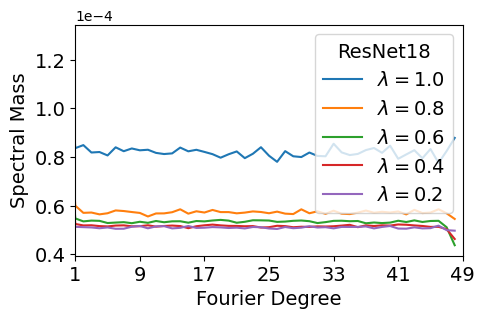

In [38]:
xticks = [1 + k*8 for k in range(7)]
make_plot(resnet18_saved, "lambda_to_max_mass", "ResNet18", "Spectral Mass", min_degree=1, max_degree=49, xticks=xticks);

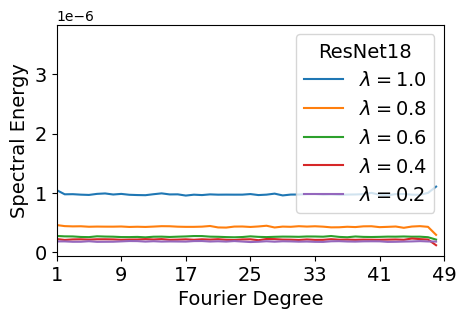

In [34]:
xticks = [1 + k*8 for k in range(7)]
make_plot(resnet18_saved, "lambda_to_max_variance", "ResNet18", "Spectral Energy", min_degree=1, max_degree=49, xticks=xticks);